# 02 — Exploratory Analysis

This notebook explores the Vela photon event dataset loaded from the FITS file.

## Objectives

- inspect photon arrival-time distribution;
- analyze photon energy distribution;
- check inter-arrival times;
- identify extreme energy values;
- prepare assumptions for preprocessing.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits


In [2]:
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "raw" / "vela_photons.fits"

data_path

WindowsPath('C:/Users/vi/pulsar-clean/data/raw/vela_photons.fits')

In [3]:
with fits.open(data_path) as hdul:
    events = hdul[1].data

    df = pd.DataFrame({
        "time": np.asarray(events["TIME"], dtype=np.float64),
        "energy": np.asarray(events["ENERGY"], dtype=np.float64)
    })

df.head()

,time,energy
0,7.804732e+08,106.341278
1,7.805337e+08,326.514008
2,7.805415e+08,207.780685
3,7.805529e+08,229.124054
4,7.805640e+08,271.309235


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 540091 entries, 0 to 540090
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    540091 non-null  float64
 1   energy  540091 non-null  float64
dtypes: float64(2)
memory usage: 8.2 MB


In [5]:
df.describe()

,time,energy
count,5.400910e+05,540091.000000
mean,7.854256e+08,657.005789
std,2.455940e+06,2017.113152
min,7.804545e+08,100.000038
25%,7.830112e+08,186.619041
50%,7.861667e+08,320.299591
75%,7.874730e+08,634.793060
max,7.901001e+08,278458.968750


The dataset contains photon arrival times and photon energy values. These two variables are the basis for the following timing analysis.

In [6]:
df["time_rel"] = df["time"] - df["time"].min()
df["dt"] = df["time"].diff()

df.head()

,time,energy,time_rel,dt
0,7.804732e+08,106.341278,18748.859121,NaN
1,7.805337e+08,326.514008,79221.431558,60472.572436
2,7.805415e+08,207.780685,87021.198388,7799.766830
3,7.805529e+08,229.124054,98457.021602,11435.823213
4,7.805640e+08,271.309235,109584.648355,11127.626753


## Photon energy distribution

The energy distribution helps identify the typical energy range of detected photons and possible high-energy outliers.

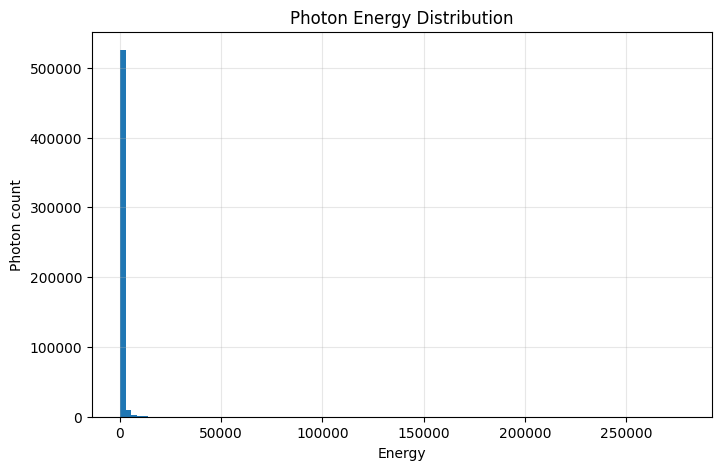

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["energy"], bins=100)
plt.xlabel("Energy")
plt.ylabel("Photon count")
plt.title("Photon Energy Distribution")
plt.grid(alpha=0.3)
plt.show()

The energy distribution is right-skewed: most photon events are concentrated at lower energies, while a smaller number of events have much higher energy values.

## Photon arrival times

The relative arrival time shows how photon events are distributed across the observation window.

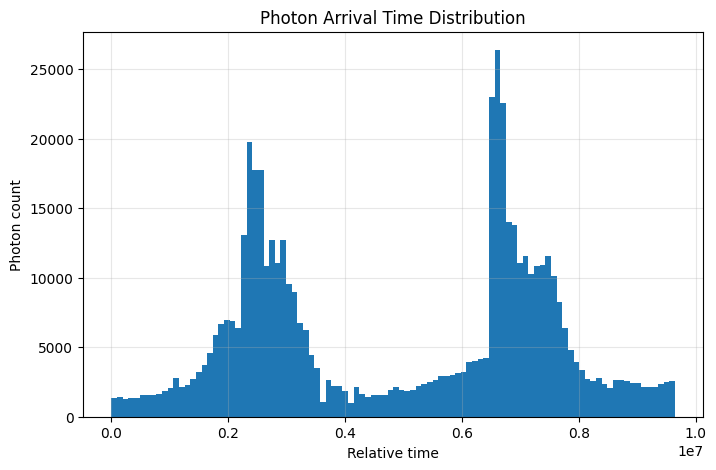

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["time_rel"], bins=100)
plt.xlabel("Relative time")
plt.ylabel("Photon count")
plt.title("Photon Arrival Time Distribution")
plt.grid(alpha=0.3)
plt.show()

The photon events are distributed across the observation interval. This confirms that the dataset contains a time series suitable for further pulsar timing analysis.

## Inter-arrival times

Inter-arrival times show the time differences between consecutive photon detections.

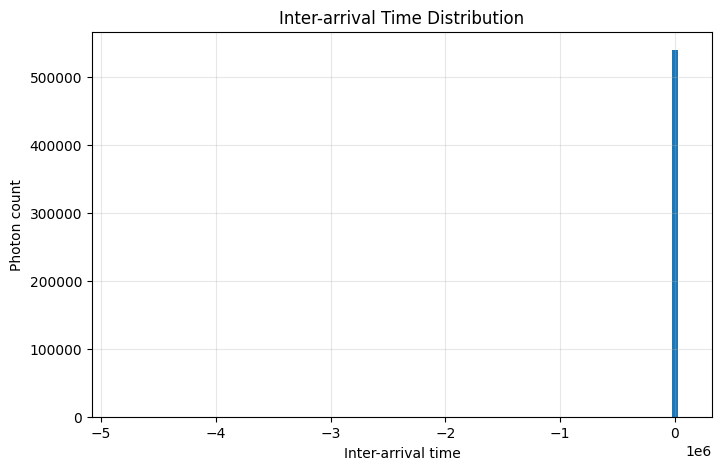

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["dt"].dropna(), bins=100)
plt.xlabel("Inter-arrival time")
plt.ylabel("Photon count")
plt.title("Inter-arrival Time Distribution")
plt.grid(alpha=0.3)
plt.show()

In [10]:
df[["time", "time_rel", "energy", "dt"]].describe()

,time,time_rel,energy,dt
count,5.400910e+05,5.400910e+05,540091.000000,5.400900e+05
mean,7.854256e+08,4.971094e+06,657.005789,1.781792e+01
std,2.455940e+06,2.455940e+06,2017.113152,2.455348e+04
min,7.804545e+08,0.000000e+00,100.000038,-4.833727e+06
25%,7.830112e+08,2.556761e+06,186.619041,1.524692e+00
50%,7.861667e+08,5.712283e+06,320.299591,5.653065e+00
75%,7.874730e+08,7.018533e+06,634.793060,2.119941e+01
max,7.901001e+08,9.645602e+06,278458.968750,7.767117e+04


## Summary

The exploratory analysis confirms that the dataset contains a large number of photon events with valid time and energy values. The energy distribution is strongly skewed, and photon arrival times cover an extended observation window. These observations support the next preprocessing step, where photon events will be filtered before period detection.